<a href="https://colab.research.google.com/github/haqiaryva/UTS-DeepLearning/blob/main/Studi_Kasus_2_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, Lambda, MaxPooling2D, Input # convolution layers
from keras.layers import Dense, Dropout, Flatten, BatchNormalization # core layers
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.utils import to_categorical

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sub = pd.read_csv('sample_submission.csv')


## Exploratory Data Analysis (EDA)


In [ ]:
print(f"Training data size is {train.shape}\nTesting data size is {test.shape}")

Training data size is (42000, 785)
Testing data size is (28000, 784)


## Preprocessing


In [ ]:
X = train.drop(['label'], axis=1).values
y = train['label'].values

In [ ]:
X = X / 255.0

In [ ]:
X = X.reshape(-1,28,28,1)

In [ ]:
y = to_categorical(y)

print(f"Label size {y.shape}")

Label size (42000, 10)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((37800, 28, 28, 1), (4200, 28, 28, 1), (37800, 10), (4200, 10))

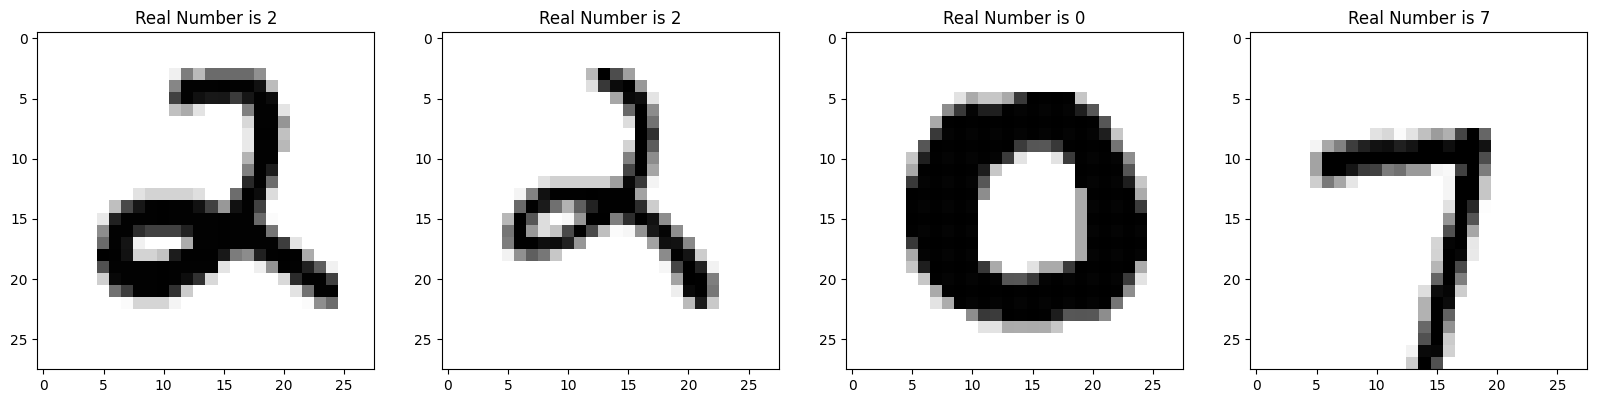

In [ ]:
X_train__ = X_train.reshape(X_train.shape[0], 28, 28)

fig, axis = plt.subplots(1, 4, figsize=(20, 10))
for i, ax in enumerate(axis.flat):
    ax.imshow(X_train__[i], cmap='binary')
    digit = y_train[i].argmax()
    ax.set(title = f"Real Number is {digit}");

In [ ]:
mean = np.mean(X_train)
std = np.std(X_train)

def standardize(x):
    return (x-mean)/std

## Modeling


In [ ]:
model = Sequential([
    Input(shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=500,
    callbacks=[early_stop],
    batch_size=128
)

Epoch 1/500
296/296 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.9210 - loss: 0.2681 - val_accuracy: 0.9710 - val_loss: 0.0893
Epoch 2/500
296/296 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - accuracy: 0.9787 - loss: 0.0699 - val_accuracy: 0.9824 - val_loss: 0.0576
Epoch 3/500
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.9855 - loss: 0.0471 - val_accuracy: 0.9824 - val_loss: 0.0520
Epoch 4/500
296/296 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.9888 - loss: 0.0364 - val_accuracy: 0.9860 - val_loss: 0.0459
Epoch 5/500
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.9911 - loss: 0.0287 - val_accuracy: 0.9902 - val_loss: 0.0394
Epoch 6/500
296/296 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.9930 - loss: 0.0222 - val_accuracy: 0.9850 - val_loss: 0.0480
Epoch 7/500
296/296 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.9940 - loss: 0.0186 - val_accuracy: 0.9860 - val_loss: 0.0451
Epoch 8/500
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9955 - loss: 0

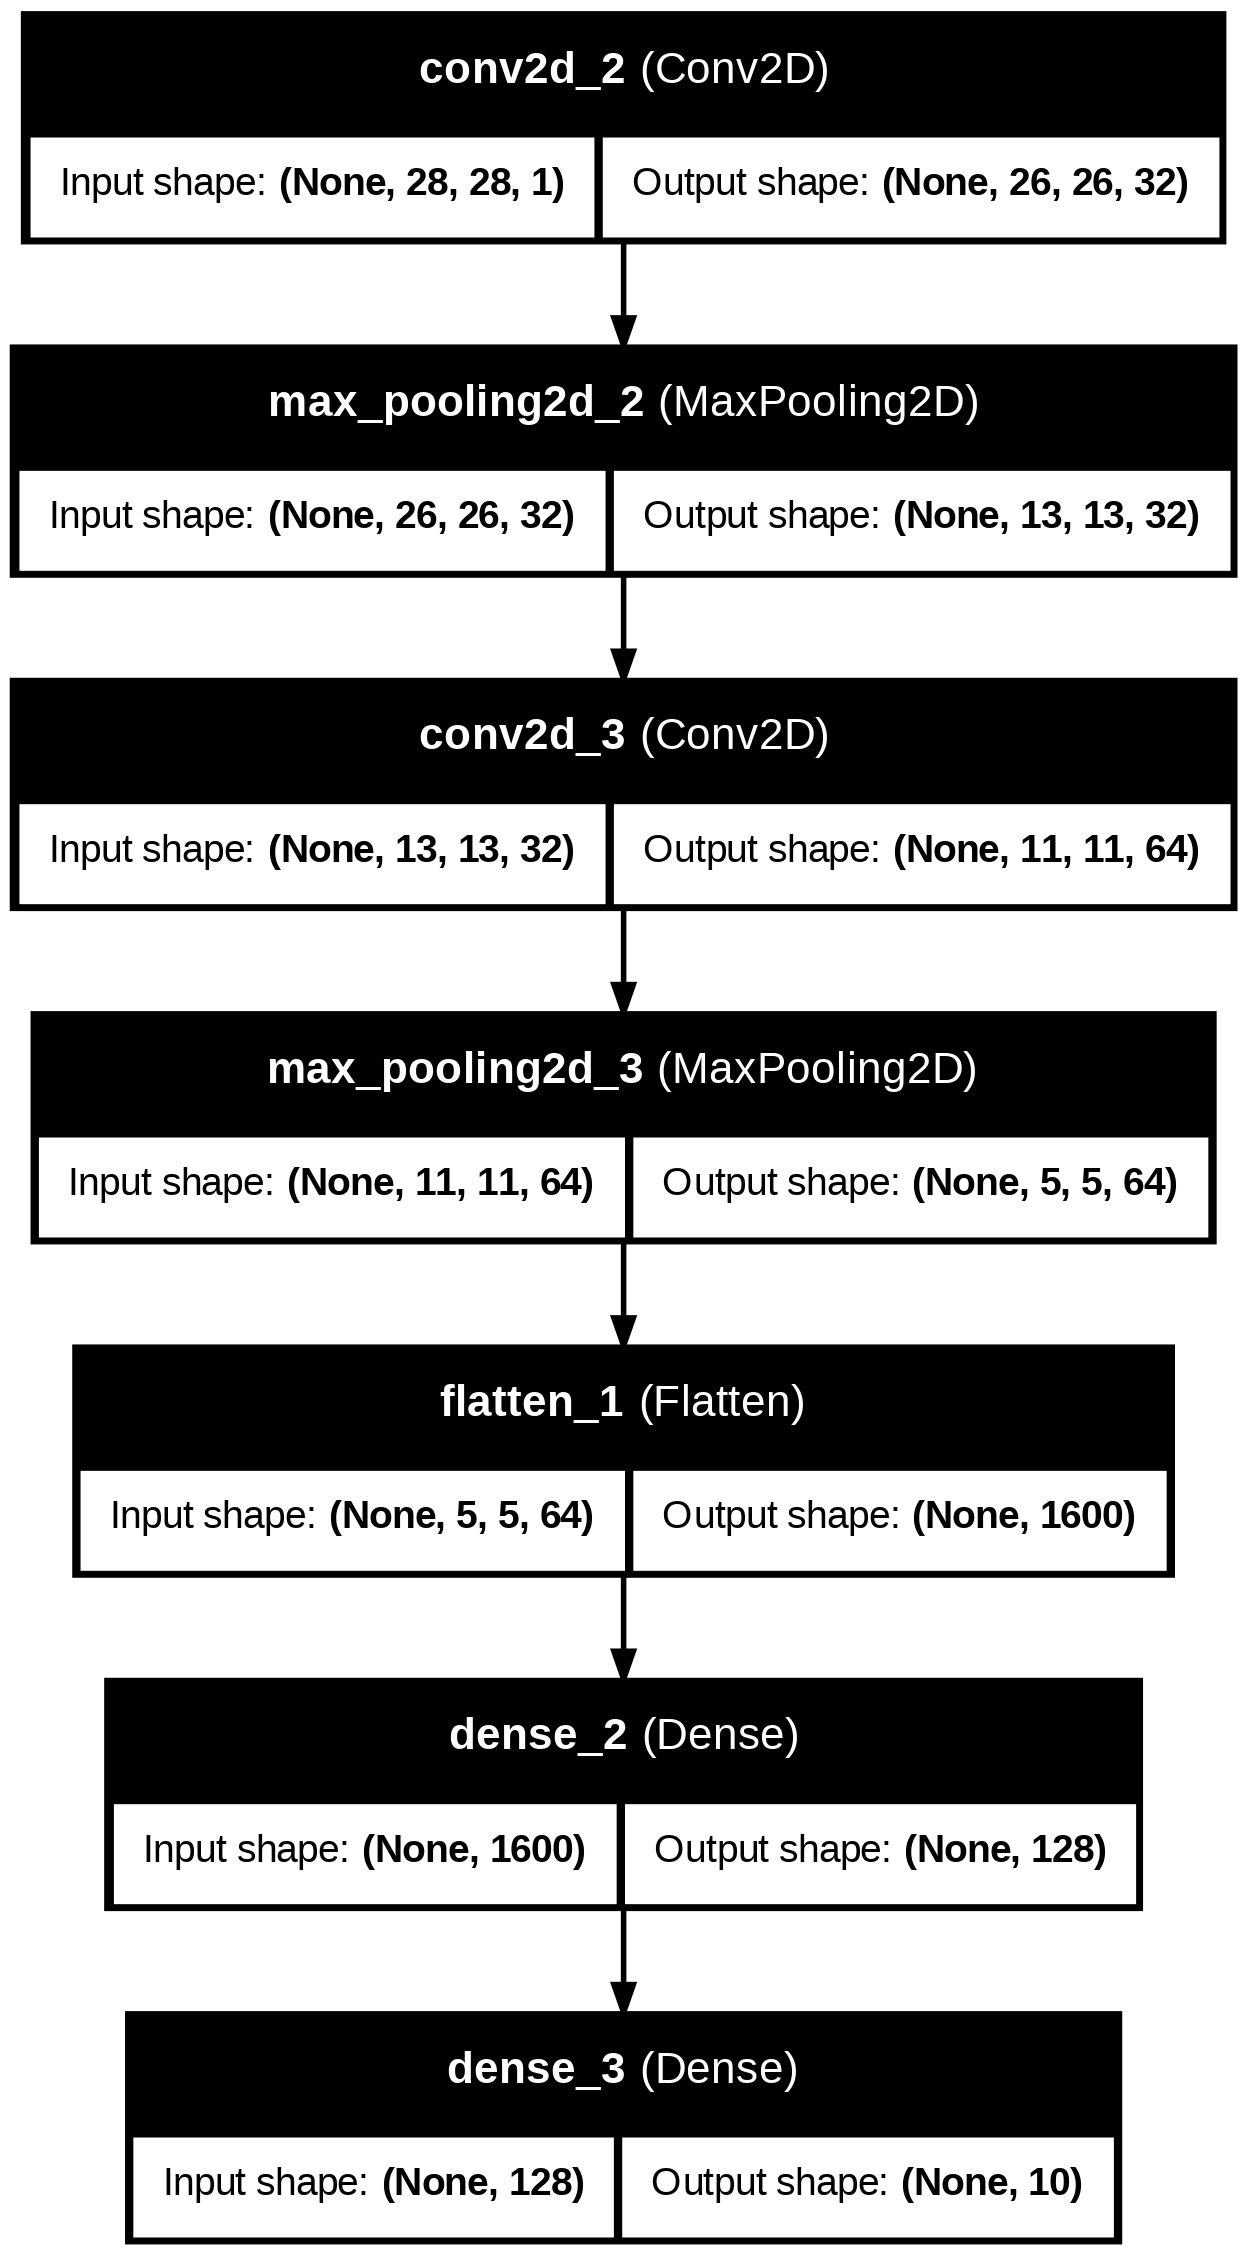

In [ ]:
from keras.utils import plot_model
plot_model(model, to_file='CNN_model_arch.png', show_shapes=True, show_layer_names=True)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

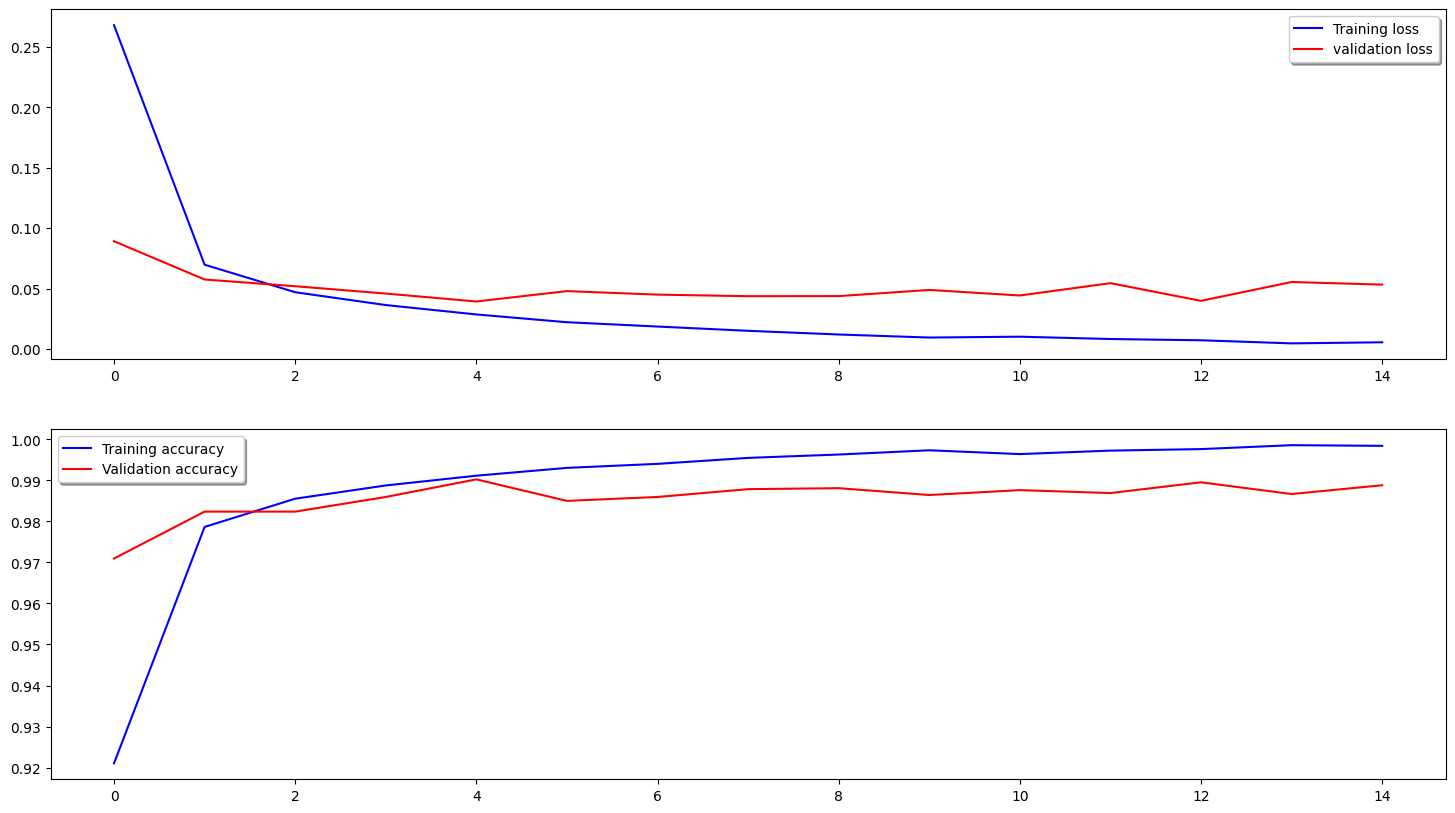

In [ ]:
# Plot the loss and accuracy curves for training and validation
fig, ax = plt.subplots(2,1, figsize=(18, 10))
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss")
legend = ax[0].legend(loc='best', shadow=True)

# Note: In newer Keras versions, use 'accuracy' instead of 'acc'
ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


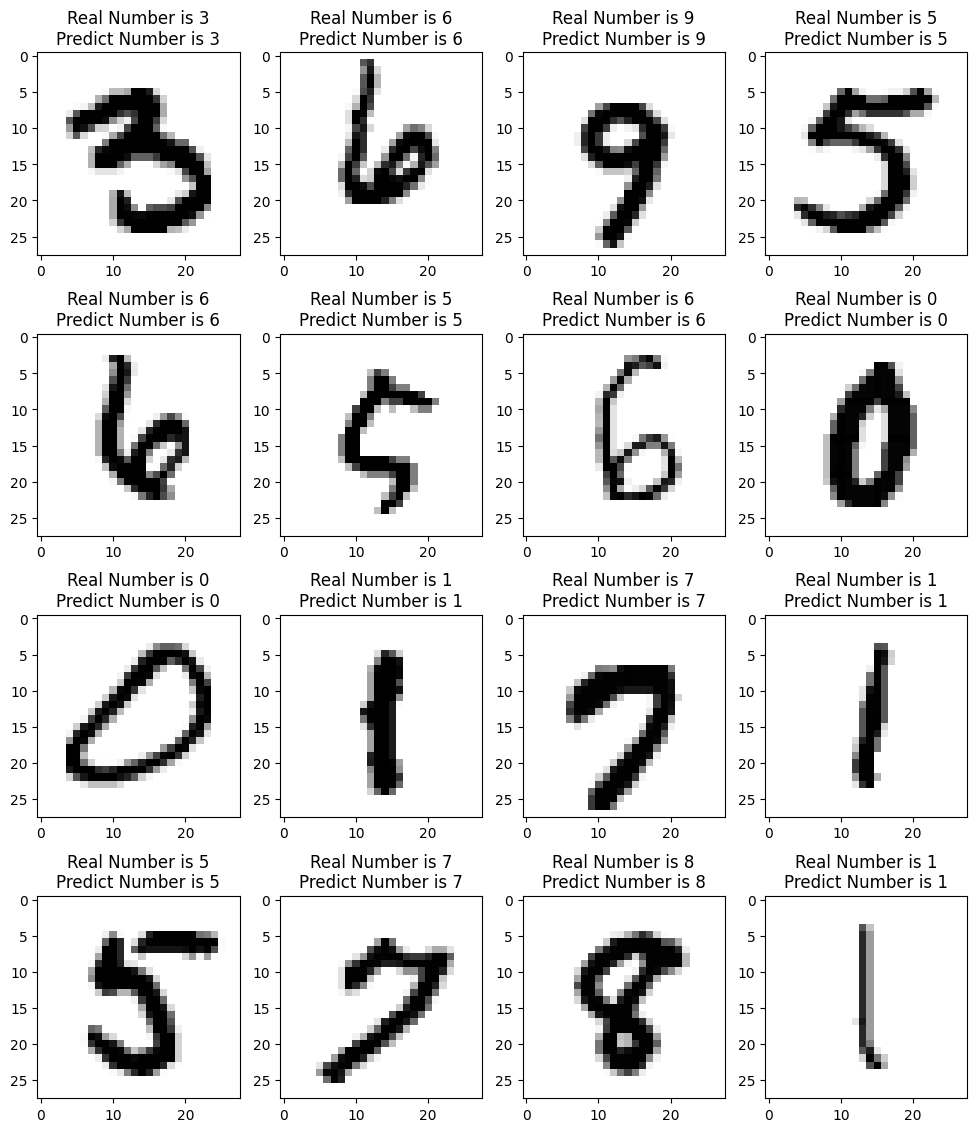

In [ ]:
y_pred = model.predict(X_test)
X_test__ = X_test.reshape(X_test.shape[0], 28, 28)

fig, axis = plt.subplots(4, 4, figsize=(12, 14))
for i, ax in enumerate(axis.flat):
    ax.imshow(X_test__[i], cmap='binary')
    ax.set(title = f"Real Number is {y_test[i].argmax()}\nPredict Number is {y_pred[i].argmax()}");

In [ ]:
# 1. Preprocessing data test
X_test_final = test.values / 255.0
X_test_final = X_test_final.reshape(-1, 28, 28, 1)

# 2. Melakukan prediksi
predictions = model.predict(X_test_final)

# 3. Mengambil index dengan probabilitas tertinggi sebagai label
results = np.argmax(predictions, axis=1)

# 4. Menyiapkan file submission
sub['Label'] = results
sub.to_csv('submission.csv', index=False)

print("Prediksi selesai! File 'submission.csv' telah berhasil dibuat.")
display(sub.head())

875/875 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
Prediksi selesai! File 'submission.csv' telah berhasil dibuat.


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
